
# 1. DEFINE PROBLEM

PROBLEM STATEMENT:

This is a multi-class classification problem where we need to predict the 
business risk level (Target variable) based on various business and owner 
characteristics.

TARGET VARIABLE:
- Low: Low risk business
- Medium: Medium risk business  
- High: High risk business

FEATURES:
- Demographic: owner_age, owner_sex, country
- Business Characteristics: business_age_years, business_age_months, business_turnover, 
  business_expenses, personal_income
- Attitudes & Perceptions: Various attitude and perception columns about insurance, 
  business environment, etc.
- Financial Behaviors: has_loan_account, has_credit_card, keeps_financial_records, etc.
- Insurance Status: has_insurance, medical_insurance, funeral_insurance, etc.

OBJECTIVE:
Build a machine learning model that can accurately classify businesses into 
Low, Medium, or High risk categories to help with risk assessment and decision making.


In [27]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')


# 2. COLLECT DATA


In [2]:
# Set plot style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


train_df = pd.read_csv('Train.csv')
print(f"Training data shape: {train_df.shape}")
print(f"Columns: {train_df.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(train_df.head())


Training data shape: (9618, 39)
Columns: ['ID', 'country', 'owner_age', 'attitude_stable_business_environment', 'attitude_worried_shutdown', 'compliance_income_tax', 'perception_insurance_doesnt_cover_losses', 'perception_cannot_afford_insurance', 'personal_income', 'business_expenses', 'business_turnover', 'business_age_years', 'motor_vehicle_insurance', 'has_mobile_money', 'current_problem_cash_flow', 'has_cellphone', 'owner_sex', 'offers_credit_to_customers', 'attitude_satisfied_with_achievement', 'has_credit_card', 'keeps_financial_records', 'perception_insurance_companies_dont_insure_businesses_like_yours', 'perception_insurance_important', 'has_insurance', 'covid_essential_service', 'attitude_more_successful_next_year', 'problem_sourcing_money', 'marketing_word_of_mouth', 'has_loan_account', 'has_internet_banking', 'has_debit_card', 'future_risk_theft_stock', 'business_age_months', 'medical_insurance', 'funeral_insurance', 'motivation_make_more_money', 'uses_friends_family_saving


# 3. CLEAN DATA


In [3]:
# Check for missing values
print("\nMissing Values Summary:")
missing_summary = train_df.isnull().sum()
missing_percentage = (train_df.isnull().sum() / len(train_df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_summary,
    'Missing Percentage': missing_percentage
})
print(missing_df[missing_df['Missing Count'] > 0])

# Check data types
print("\nData Types:")
print(train_df.dtypes)

# Check for duplicates
print(f"\nDuplicate rows: {train_df.duplicated().sum()}")

# Check unique values in categorical columns
categorical_cols = train_df.select_dtypes(include=['object']).columns
print(f"\nCategorical columns: {categorical_cols.tolist()}")



Missing Values Summary:
                                                    Missing Count  \
attitude_stable_business_environment                            2   
attitude_worried_shutdown                                       2   
compliance_income_tax                                           4   
perception_insurance_doesnt_cover_losses                        5   
perception_cannot_afford_insurance                              5   
personal_income                                               109   
business_expenses                                             229   
business_turnover                                             216   
business_age_years                                            252   
motor_vehicle_insurance                                      2244   
has_mobile_money                                             2751   
current_problem_cash_flow                                    3778   
has_cellphone                                                1944   
owner_sex

# Handle missing values

In [4]:
numerical_cols = train_df.select_dtypes(include=[np.number]).columns.drop('Target', errors='ignore').tolist()
categorical_cols = train_df.select_dtypes(include=['object']).columns.drop('Target', errors='ignore').tolist()

print(f"\nNumerical columns: {len(numerical_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

# Create a copy for cleaning
df_clean = train_df.copy()

# Impute missing values
for col in numerical_cols:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f"Imputed {col} with median: {median_val}")

for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_val, inplace=True)
        print(f"Imputed {col} with mode: {mode_val}")

# Check if Target column has any issues
print(f"\nTarget variable distribution:")
print(df_clean['Target'].value_counts())


Numerical columns: 6
Categorical columns: 32
Imputed personal_income with median: 2000.0
Imputed business_expenses with median: 3000.0
Imputed business_turnover with median: 6000.0
Imputed business_age_years with median: 4.0
Imputed business_age_months with median: 3.0
Imputed attitude_stable_business_environment with mode: Yes
Imputed attitude_worried_shutdown with mode: No
Imputed compliance_income_tax with mode: No
Imputed perception_insurance_doesnt_cover_losses with mode: No
Imputed perception_cannot_afford_insurance with mode: Yes
Imputed motor_vehicle_insurance with mode: Never had
Imputed has_mobile_money with mode: Have now
Imputed current_problem_cash_flow with mode: Yes
Imputed has_cellphone with mode: Yes
Imputed owner_sex with mode: Female
Imputed offers_credit_to_customers with mode: Yes, sometimes
Imputed attitude_satisfied_with_achievement with mode: Yes
Imputed has_credit_card with mode: Never had
Imputed keeps_financial_records with mode: No
Imputed perception_insura


# 4. PREPROCESS


In [22]:
# Separate features and target
X = train_df.drop('Target', axis=1)
y = train_df['Target']

# Identify numerical and categorical feature columns
numerical_feature_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_feature_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical features: {len(numerical_feature_cols)}")
print(f"Categorical features: {len(categorical_feature_cols)}")



Numerical features: 6
Categorical features: 32


In [23]:
# Encode target variable
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)
print(f"Target classes: {target_encoder.classes_}")
print(f"Target encoding: {dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_)))}")



Target classes: ['High' 'Low' 'Medium']
Target encoding: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


In [24]:
# Create preprocessing pipelines
# Numerical pipeline: impute missing values with median, then scale
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [25]:
# Categorical pipeline: impute missing values with most frequent, then one-hot encode
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [28]:
# Combine pipelines
preprocessor = ColumnTransformer([
    ('numerical', numerical_pipeline, numerical_feature_cols),
    ('categorical', categorical_pipeline, categorical_feature_cols)
])

In [29]:
# Create full pipeline with preprocessor and classifier
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])



In [30]:
# Split data BEFORE fitting (to avoid data leakage)
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nTraining set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")


Training set: (7694, 38)
Validation set: (1924, 38)



# 5. EXPLORE


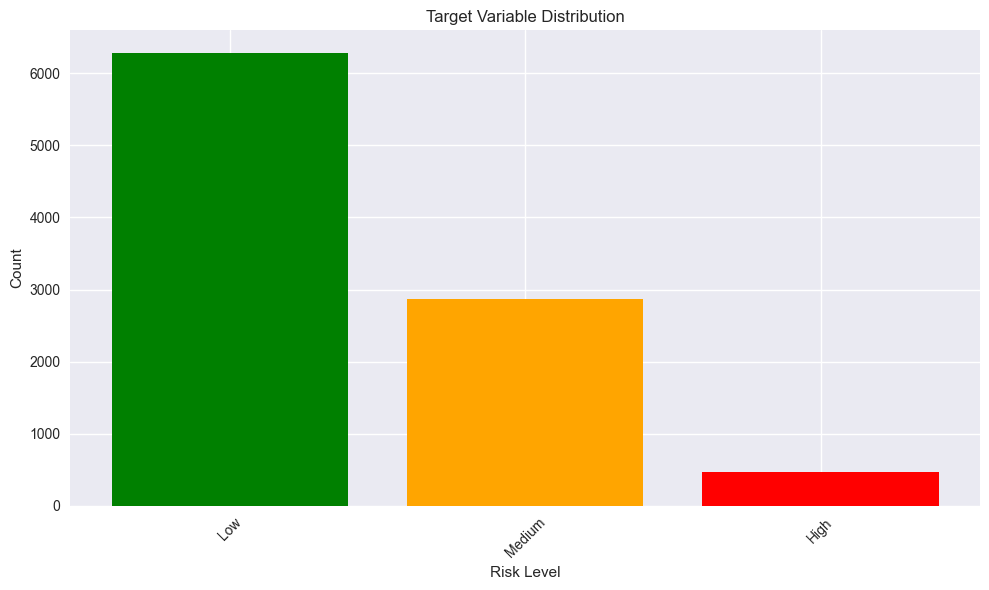

In [31]:
# Create visualization directory
import os
os.makedirs('visualizations', exist_ok=True)

# Target distribution
plt.figure(figsize=(10, 6))
target_counts = df_clean['Target'].value_counts()
plt.bar(target_counts.index, target_counts.values, color=['green', 'orange', 'red'])
plt.xlabel('Risk Level')
plt.ylabel('Count')
plt.title('Target Variable Distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('visualizations/target_distribution.png', dpi=300)
plt.show()



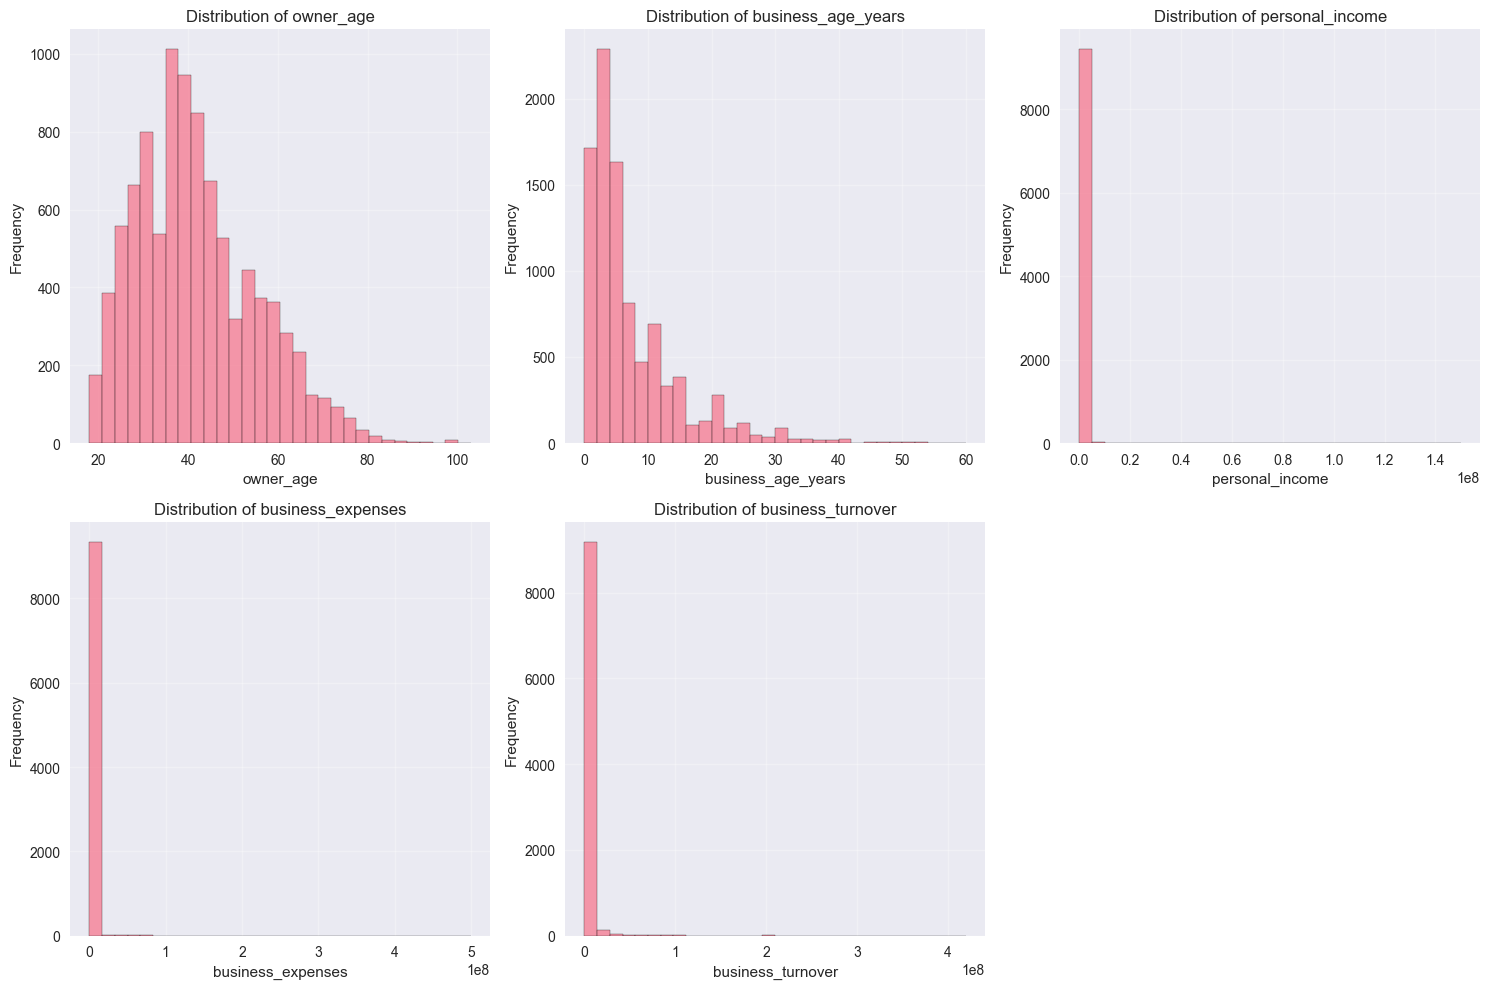

In [32]:
# Numerical features distribution
plt.figure(figsize=(15, 10))
numerical_features = ['owner_age', 'business_age_years', 'personal_income', 
                      'business_expenses', 'business_turnover']
for i, col in enumerate(numerical_features):
    plt.subplot(2, 3, i+1)
    plt.hist(df_clean[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {col}')
    plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('visualizations/numerical_distribution.png', dpi=300)
plt.show()

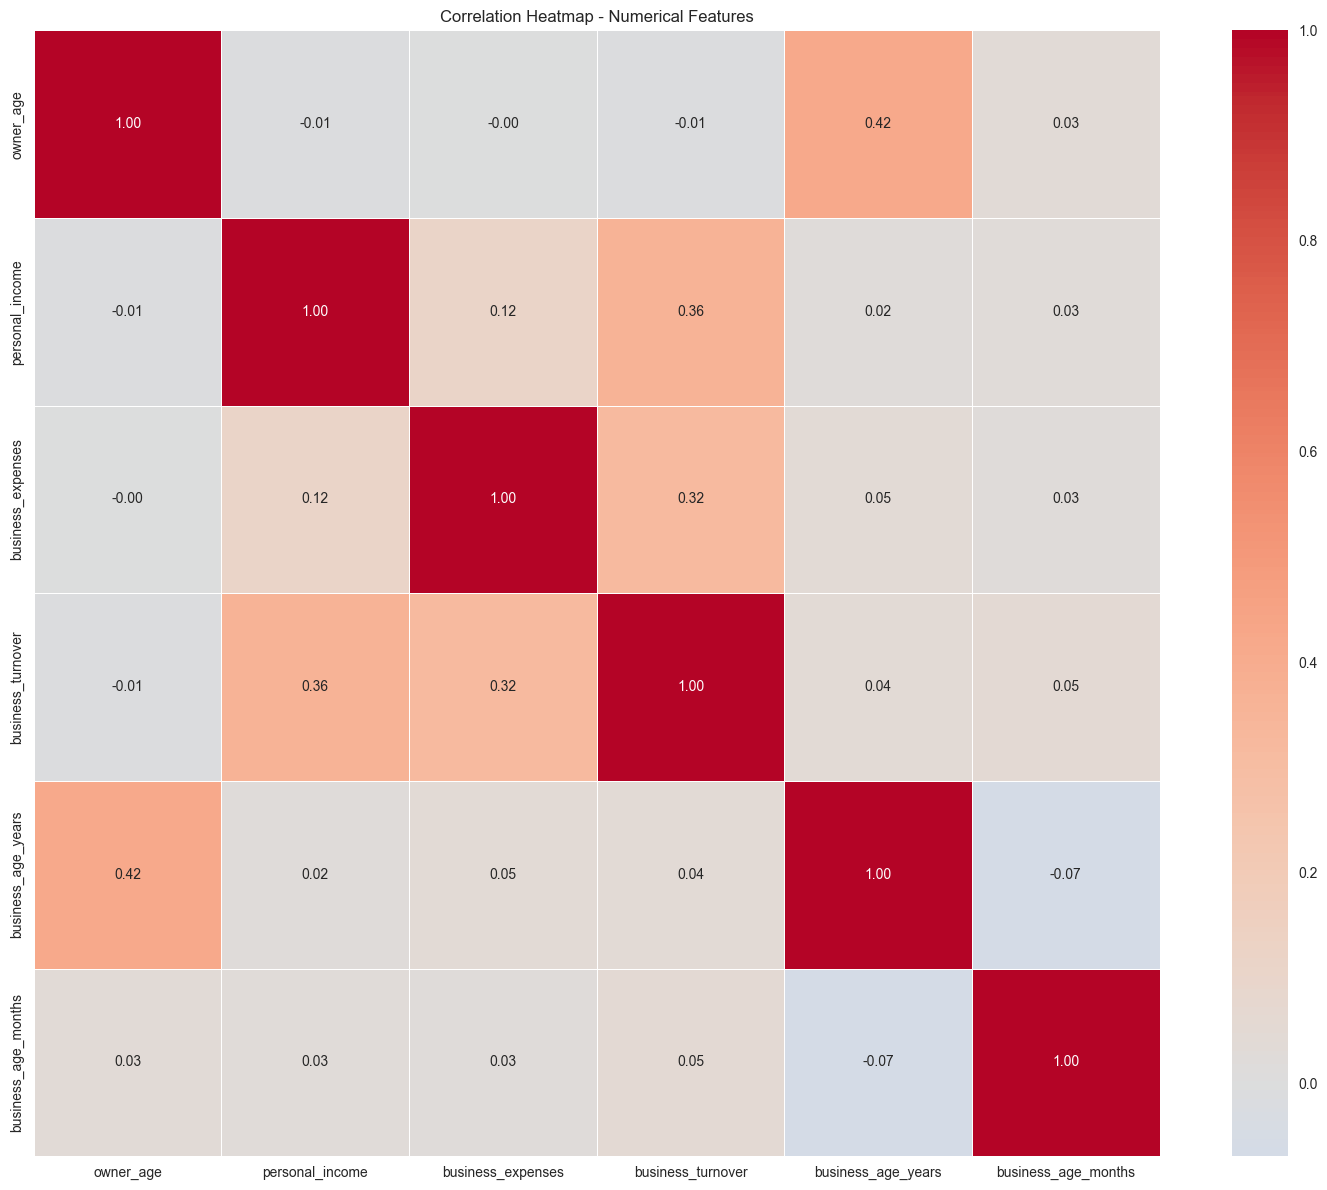

In [33]:
# Correlation heatmap
plt.figure(figsize=(15, 12))
corr_cols = numerical_cols[:10]  # Top 10 numerical columns
corr_matrix = df_clean[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation Heatmap - Numerical Features')
plt.tight_layout()
plt.savefig('visualizations/correlation_heatmap.png', dpi=300)
plt.show()

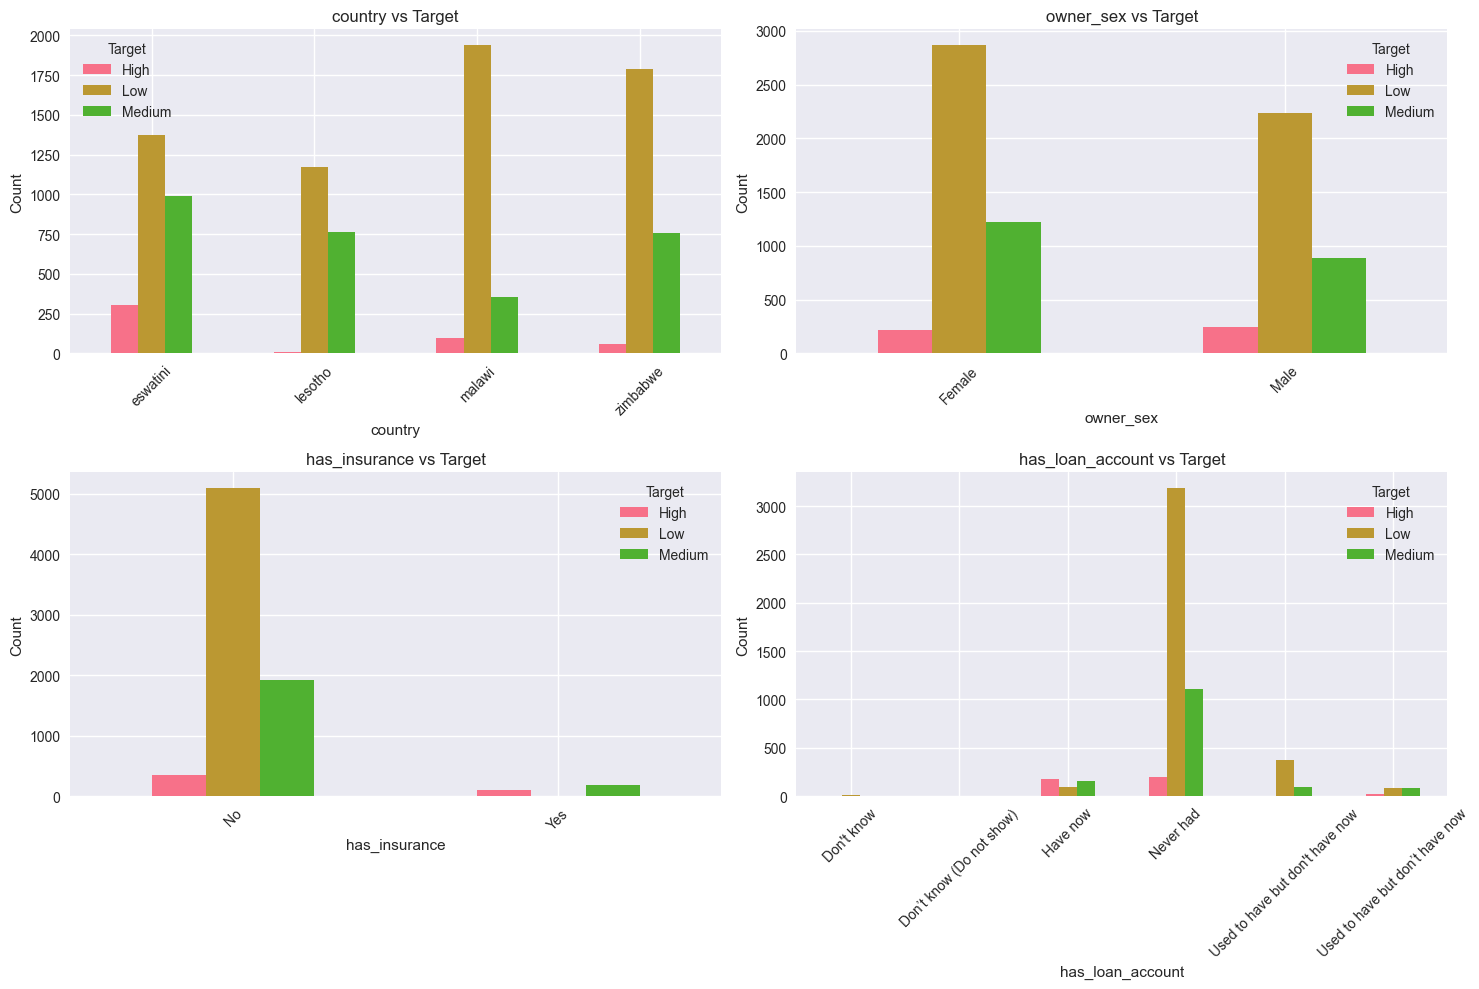

In [34]:
# Categorical features vs Target
plt.figure(figsize=(15, 10))
categorical_features = ['country', 'owner_sex', 'has_insurance', 'has_loan_account']
for i, col in enumerate(categorical_features):
    if col in df_clean.columns:
        plt.subplot(2, 2, i+1)
        pd.crosstab(df_clean[col], df_clean['Target']).plot(kind='bar', ax=plt.gca())
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.title(f'{col} vs Target')
        plt.xticks(rotation=45)
        plt.legend(title='Target')
plt.tight_layout()
plt.savefig('visualizations/categorical_vs_target.png', dpi=300)
plt.show()

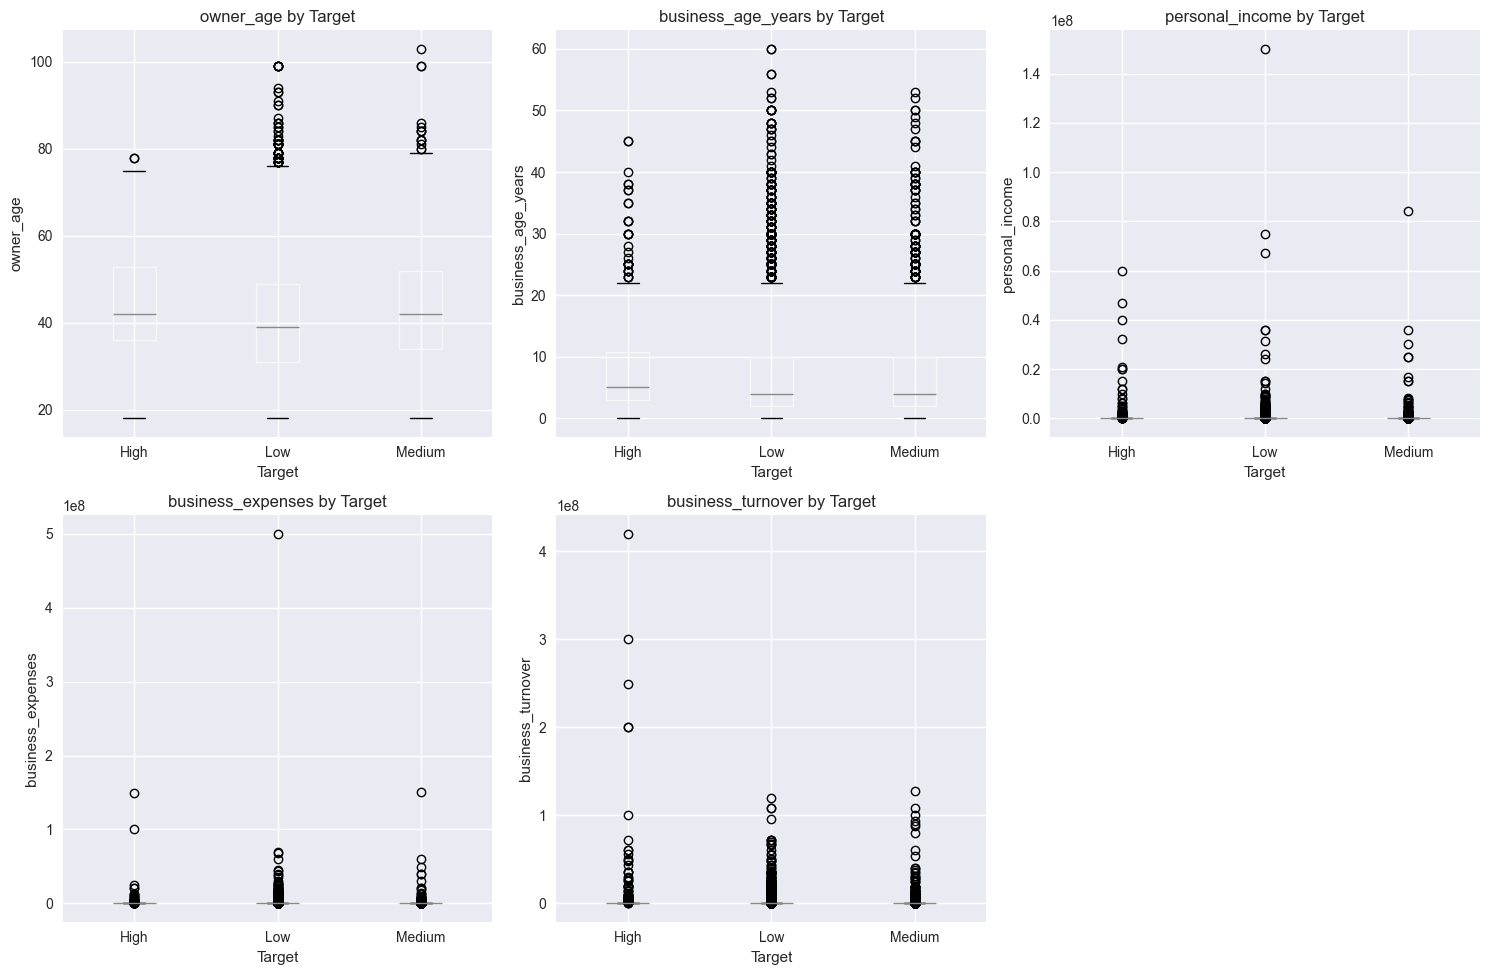

In [35]:
# Box plots for numerical features by target
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features[:5]):
    plt.subplot(2, 3, i+1)
    df_clean.boxplot(column=col, by='Target', ax=plt.gca())
    plt.xlabel('Target')
    plt.ylabel(col)
    plt.title(f'{col} by Target')
    plt.suptitle('')
plt.tight_layout()
plt.savefig('visualizations/boxplot_by_target.png', dpi=300)
plt.show()


# 6. ANALYZE

In [36]:
# Statistical summary
print("\nStatistical Summary of Numerical Features:")
print(df_clean[numerical_cols].describe())


Statistical Summary of Numerical Features:
         owner_age  personal_income  business_expenses  business_turnover  \
count  9618.000000     9.509000e+03       9.389000e+03       9.402000e+03   
mean     41.705344     2.627345e+05       4.583838e+05       1.348210e+06   
std      13.314010     2.566268e+06       6.184746e+06       8.804741e+06   
min      18.000000     0.000000e+00       0.000000e+00       0.000000e+00   
25%      32.000000     3.000000e+02       7.000000e+02       1.500000e+03   
50%      40.000000     2.000000e+03       3.000000e+03       6.000000e+03   
75%      50.000000     2.500000e+04       2.500000e+04       5.000000e+04   
max     103.000000     1.500000e+08       5.000000e+08       4.200000e+08   

       business_age_years  business_age_months  
count         9366.000000          5507.000000  
mean             7.030536             3.636281  
std              7.650349             3.386488  
min              0.000000             0.000000  
25%              

In [37]:
# Feature importance analysis (preliminary)
print("\nFeature Correlation with Target:")
correlations = df_clean[numerical_cols].corrwith(df_processed['Target_encoded'])
correlations = correlations.abs().sort_values(ascending=False)
print(correlations.head(10))



Feature Correlation with Target:
business_turnover      0.075888
owner_age              0.049390
personal_income        0.040067
business_age_years     0.024372
business_expenses      0.023472
business_age_months    0.001511
dtype: float64


In [14]:
# Business insights
print("\nKey Business Insights:")
print(f"1. Average owner age: {df_clean['owner_age'].mean():.2f} years")
print(f"2. Average business age: {df_clean['business_age_years'].mean():.2f} years")
print(f"3. Average personal income: {df_clean['personal_income'].mean():.2f}")
print(f"4. Average business turnover: {df_clean['business_turnover'].mean():.2f}")


Key Business Insights:
1. Average owner age: 41.71 years
2. Average business age: 7.03 years
3. Average personal income: 262734.47
4. Average business turnover: 1348209.72


In [15]:
# Country distribution
if 'country' in df_clean.columns:
    print(f"\n5. Country distribution:")
    print(df_clean['country'].value_counts())


5. Country distribution:
country
eswatini    2674
zimbabwe    2612
malawi      2388
lesotho     1944
Name: count, dtype: int64


In [16]:
# Risk level by country
if 'country' in df_clean.columns:
    print(f"\n6. Risk level by country:")
    print(pd.crosstab(df_clean['country'], df_clean['Target'], normalize='index'))



6. Risk level by country:
Target        High       Low    Medium
country                               
eswatini  0.114809  0.514211  0.370980
lesotho   0.003086  0.603909  0.393004
malawi    0.040201  0.812395  0.147404
zimbabwe  0.023354  0.685681  0.290965



# 7. MODELLING

In [41]:
print(X_train.shape)

(7694, 38)


In [47]:
# Define models to try
models = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
    ]),
    ##'Gradient Boosting': Pipeline([
    ##    ('preprocessor', preprocessor),
      ##  ('classifier', GradientBoostingClassifier(n_estimators=100, max_depth=3))
    ##])
}

In [48]:
# Train and evaluate models
results = {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)
    
    # Metrics
    train_acc = accuracy_score(y_train, y_pred_train)
    val_acc = accuracy_score(y_val, y_pred_val)
    
    results[name] = {
        'model': model,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'y_pred_val': y_pred_val
    }
    
    print(f"  Training Accuracy: {train_acc:.4f}")
    print(f"  Validation Accuracy: {val_acc:.4f}")
    print(f"  Classification Report:")
    print(classification_report(y_val, y_pred_val, target_names=target_encoder.classes_))


Training Logistic Regression...
  Training Accuracy: 0.9509
  Validation Accuracy: 0.8311
  Classification Report:
              precision    recall  f1-score   support

        High       0.59      0.71      0.65        94
         Low       0.89      0.90      0.90      1256
      Medium       0.74      0.70      0.72       574

    accuracy                           0.83      1924
   macro avg       0.74      0.77      0.75      1924
weighted avg       0.83      0.83      0.83      1924


Training Random Forest...
  Training Accuracy: 1.0000
  Validation Accuracy: 0.8285
  Classification Report:
              precision    recall  f1-score   support

        High       1.00      0.33      0.50        94
         Low       0.83      0.97      0.90      1256
      Medium       0.80      0.60      0.69       574

    accuracy                           0.83      1924
   macro avg       0.88      0.63      0.69      1924
weighted avg       0.83      0.83      0.81      1924



In [50]:
best_model_name = max(results, key=lambda x: results[x]['val_acc'])
best_model = results[best_model_name]['model']
print(f"\nBest Model: {best_model_name} with validation accuracy: {results[best_model_name]['val_acc']:.4f}")


Best Model: Logistic Regression with validation accuracy: 0.8311


In [51]:
# Cross-validation on best model
print("\nCross-Validation Scores:")
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"CV Scores: {cv_scores}")
print(f"Mean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


Cross-Validation Scores:
CV Scores: [0.85640026 0.83495776 0.83235867 0.84080572 0.8426528 ]
Mean CV Score: 0.8414 (+/- 0.0167)



# 8. VISUALIZE


In [1]:
# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_val, results[best_model_name]['y_pred_val'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.savefig('visualizations/confusion_matrix.png', dpi=300)
plt.show()

NameError: name 'plt' is not defined

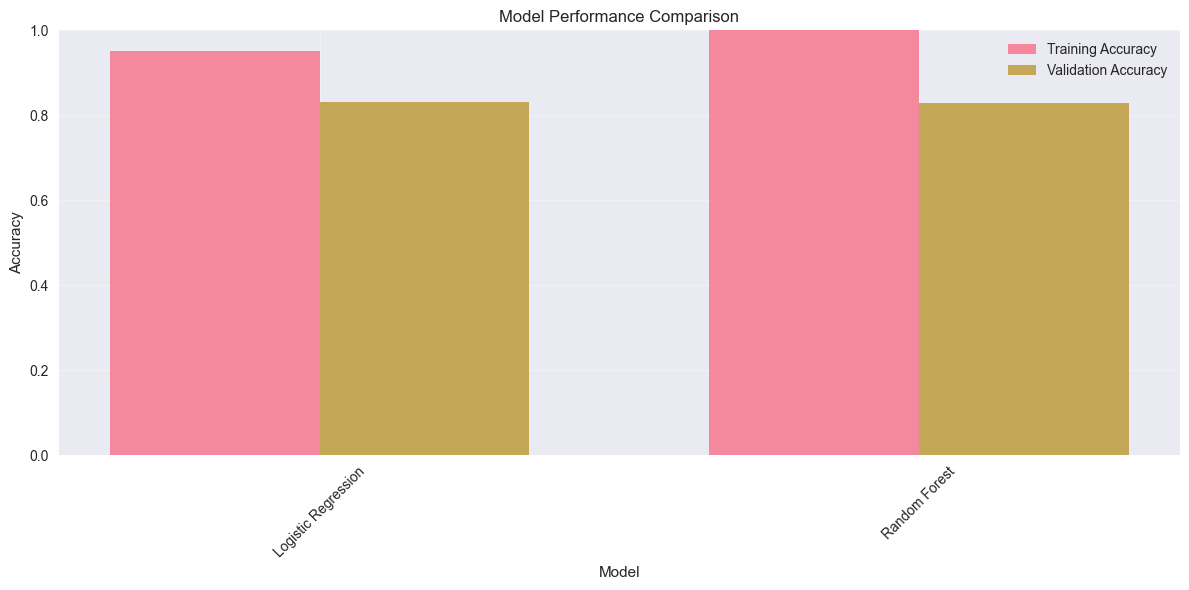

In [ ]:
# Model comparison
plt.figure(figsize=(12, 6))
model_names = list(results.keys())
train_accs = [results[name]['train_acc'] for name in model_names]
val_accs = [results[name]['val_acc'] for name in model_names]

x = np.arange(len(model_names))
width = 0.35

plt.bar(x - width/2, train_accs, width, label='Training Accuracy', alpha=0.8)
plt.bar(x + width/2, val_accs, width, label='Validation Accuracy', alpha=0.8)
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Performance Comparison')
plt.xticks(x, model_names, rotation=45)
plt.legend()
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('visualizations/model_comparison.png', dpi=300)
plt.show()


# CREATE TEST.CSV AND SUBMISSION.CSV


In [57]:
# Create test.csv (same as train but without Target column)
test_df = train_df.drop('Target', axis=1)
test_df.to_csv('test.csv', index=False)
print(f"Created test.csv with shape: {test_df.shape}")

# Make predictions on test data using the best model
test_predictions = best_model.predict(test_df)
test_predictions_decoded = target_encoder.inverse_transform(test_predictions)

# Create submission.csv
submission_df = pd.DataFrame({
    'ID': test_df['ID'],
    'Target': test_predictions_decoded
})
submission_df.to_csv('submission.csv', index=False)
print(f"Created submission.csv with shape: {submission_df.shape}")
print(f"\nSubmission preview:")
print(submission_df.head(10))
print(f"\nTarget distribution in submission:")
print(submission_df['Target'].value_counts())

Created test.csv with shape: (9618, 38)
Created submission.csv with shape: (9618, 2)

Submission preview:
          ID  Target
0  ID_3CFL0U     Low
1  ID_XWI7G3  Medium
2  ID_TY93LV     Low
3  ID_9OP2C8     Low
4  ID_13REYS     Low
5  ID_57I1NI     Low
6  ID_L3TKQV  Medium
7  ID_KB700U     Low
8  ID_DUQI8U  Medium
9  ID_27YH6U    High

Target distribution in submission:
Target
Low       6356
Medium    2705
High       557
Name: count, dtype: int64
